In [2]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd

In [3]:
path = kagglehub.dataset_download("sumit17125/red-wine-quality-dataset")
df = pd.read_csv(path + "/winequality-red.csv",sep=';')

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
np.random.seed(42)
X = np.random.randn(300, 2)

In [4]:
X.shape


(300, 2)

In [5]:
X[:100] += 5  # Cluster 1
X[100:200] += np.array([5, 5])  # Cluster 2

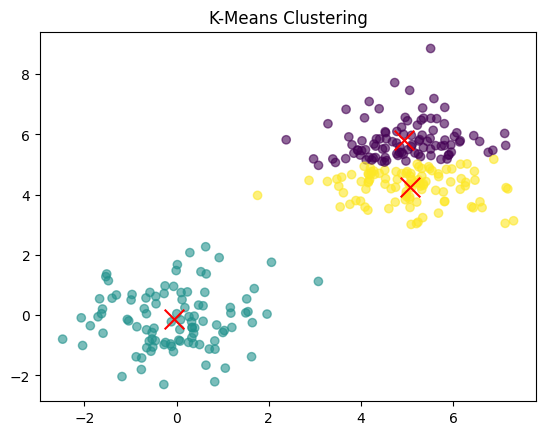

Cluster labels: [2 0 2 0 0 2 2 2 0 2 2 2 0 0 2 0 2 2 2 0 0 2 2 0 2 2 0 0 2 0 2 2 0 0 2 0 0
 0 2 2 0 2 2 0 0 0 2 2 0 2 2 2 0 2 2 0 0 0 2 0 2 2 0 2 2 0 0 0 2 2 0 0 0 2
 0 0 0 2 0 0 0 2 0 0 2 2 0 0 0 0 2 0 0 2 2 0 2 0 0 2 0 0 2 0 0 0 0 0 2 0 2
 2 0 2 0 0 2 0 0 0 2 0 2 2 0 0 0 2 2 0 2 2 2 2 0 2 2 0 2 2 0 2 2 0 2 2 0 2
 0 0 2 0 0 2 2 0 0 2 2 2 0 0 2 0 0 2 2 2 2 2 0 2 0 2 2 0 2 2 2 2 0 0 2 2 2
 0 0 2 0 2 2 2 0 0 2 0 0 2 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]
Centroids:
 [[ 4.94708034  5.80737861]
 [-0.04503739 -0.12627268]
 [ 5.06560413  4.27013136]]


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

plt.scatter(X[:,0], X[:, 1], c=labels,cmap='viridis', alpha=0.6)
plt.scatter(centroids[:,0],centroids[:,1], c='red',marker='x', s=200)
plt.title('K-Means Clustering')
plt.show()

print("Cluster labels:", labels)
print("Centroids:\n", centroids)

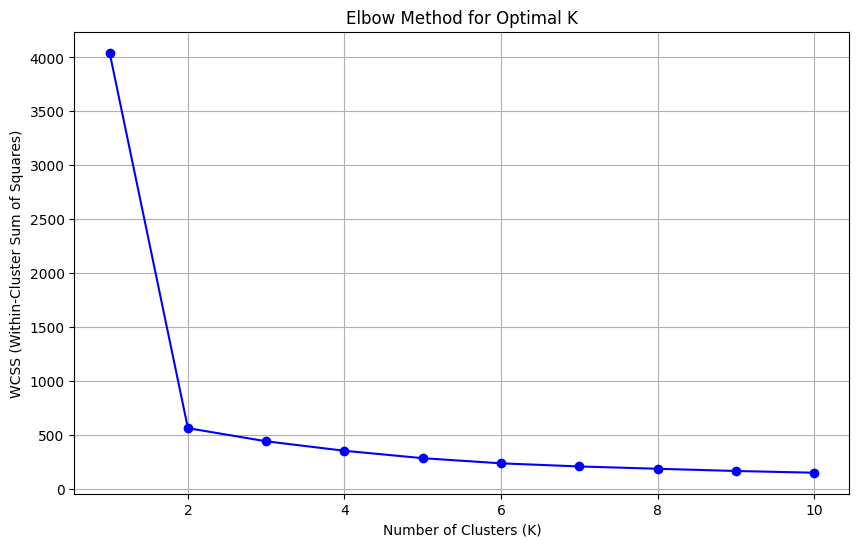

In [8]:
# Elbow method

wcss = []
k_range = range(1,11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(k_range, wcss, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()


In [9]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = {
    'age': [25, 45, 35, 23, 50, 31, 28, 42, 39, 26],
    'income': [50000, 120000, 85000, 45000, 150000, 75000, 48000, 110000, 95000, 52000],
    'spending': [3000, 15000, 8000, 2800, 20000, 7000, 3200, 18000, 11000, 3500]
}

df = pd.DataFrame(data)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

print('Customer Segments:')
print(df.groupby('cluster').agg({
    'age':['mean','count'],
    'income':'mean',
    'spending':'mean'
}))

Customer Segments:
               age               income      spending
              mean count           mean          mean
cluster                                              
0        25.500000     4   48750.000000   3125.000000
1        45.666667     3  126666.666667  17666.666667
2        35.000000     3   85000.000000   8666.666667
